# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [9]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [10]:
import pandas as pd
import os

train_path = 'matches_df_train.csv'
test_path = 'matches_df_test.csv'

matches_train = pd.read_csv(train_path)
matches_test = pd.read_csv(test_path)

train_shape = matches_train.shape
test_shape = matches_test.shape

train_size_mb = os.path.getsize(train_path) / (1024 * 1024)
test_size_mb = os.path.getsize(test_path) / (1024 * 1024)

print(f"Объем файла 'matches_df_train.csv': {train_size_mb:.2f} Мб, shape: {train_shape}")
print(f"Объем файла 'matches_df_test.csv': {test_size_mb:.2f} Мб, shape: {test_shape}")

print("\nПервая часть train датасета:")
print(matches_train.head())

print("\nКолонки в train:")
print(matches_train.columns.tolist())

print("\nПервая часть test датасета:")
print(matches_test.head())

print("\nКолонки в test:")
print(matches_test.columns.tolist())

Объем файла 'matches_df_train.csv': 28.96 Мб, shape: (641090, 7)
Объем файла 'matches_df_test.csv': 2.08 Мб, shape: (59748, 5)

Первая часть train датасета:
   match_id        date        region  game_mode  duration  radiant_win  \
0         1  2024-02-12   Europe West          4      2625        False   
1         2  2024-04-08  South Africa          2      7526         True   
2         3  2024-06-16       SE Asia          1      2831         True   
3         4  2024-09-16   Middle East         22      1438        False   
4         5  2024-03-31  South Africa         22      2051         True   

   avg_mmr  
0   3519.7  
1   2330.9  
2   1579.6  
3      NaN  
4      NaN  

Колонки в train:
['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win', 'avg_mmr']

Первая часть test датасета:
   match_id        date       region  game_mode  avg_mmr
0         8  2024-12-01        China          1   2305.0
1        29  2024-12-17  Europe West         22      NaN
2        34  2

Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

In [29]:
print(matches_train['radiant_win'].value_counts(normalize=True))

radiant_win
True     0.510772
False    0.489228
Name: proportion, dtype: float64


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** Да, Gini подходящая метрика, но при значительном имбалансе лучше рассмотреть AUC-PR.
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

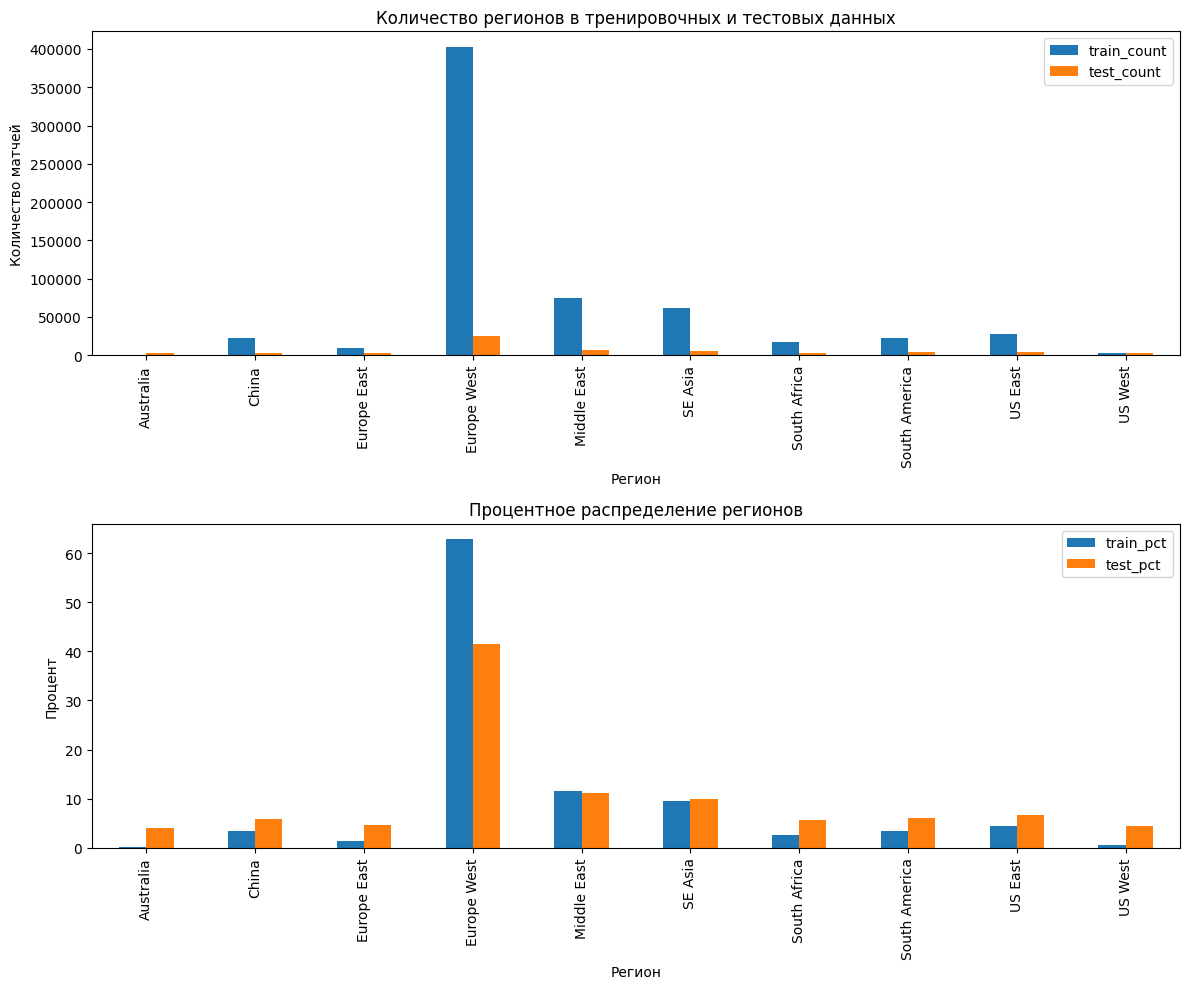

In [31]:
import matplotlib.pyplot as plt

train_region_counts = matches_train['region'].value_counts()
train_region_pct = matches_train['region'].value_counts(normalize=True) * 100

test_region_counts = matches_test['region'].value_counts()
test_region_pct = matches_test['region'].value_counts(normalize=True) * 100

region_df = pd.DataFrame({
    'train_count': train_region_counts,
    'train_pct': train_region_pct,
    'test_count': test_region_counts,
    'test_pct': test_region_pct
}).fillna(0) 

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

region_df[['train_count', 'test_count']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Количество регионов в тренировочных и тестовых данных')
axes[0].set_ylabel('Количество матчей')
axes[0].set_xlabel('Регион')

region_df[['train_pct', 'test_pct']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Процентное распределение регионов')
axes[1].set_ylabel('Процент')
axes[1].set_xlabel('Регион')

plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:** Регионы встречаются по-разному, но они сами по себе не указывают на результат. Они мало помогают предсказывать победу, поэтому их не стоит полагаться как основной сигнал. 
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

In [34]:
!pip install -qU category-encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** Target Encoder лучше, потому что он показывает, как категории связаны с исходом, и может дать более точные признаки.
</div>

Закодируйте колонку `region` выбранным вами способом

In [36]:
import category_encoders as ce
target_encoder = ce.TargetEncoder()
matches_train['region_encoded'] = target_encoder.fit_transform(matches_train['region'], matches_train['radiant_win'])
matches_test['region_encoded'] = target_encoder.transform(matches_test['region'])

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

Index(['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win',
       'avg_mmr', 'region_encoded'],
      dtype='object')


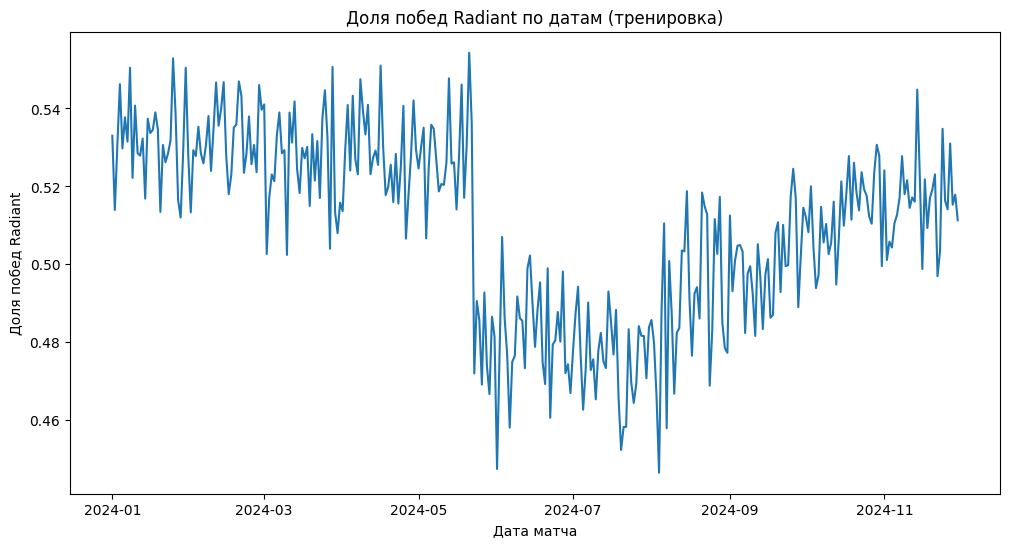

Диапазон дат в тренировочных данных: 2024-01-01 00:00:00 2024-11-30 00:00:00
Диапазон дат в тестовых данных: 2024-12-01 00:00:00 2024-12-31 00:00:00


In [38]:
import matplotlib.pyplot as plt

print(matches_train.columns)
matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])

train_grouped = matches_train.groupby('date').agg(
    total=('radiant_win', 'size'),
    radiant_wins=('radiant_win', 'sum')
)
train_grouped['radiant_win_ratio'] = train_grouped['radiant_wins'] / train_grouped['total']

plt.figure(figsize=(12,6))
plt.plot(train_grouped.index, train_grouped['radiant_win_ratio'])
plt.xlabel('Дата матча')
plt.ylabel('Доля побед Radiant')
plt.title('Доля побед Radiant по датам (тренировка)')
plt.show()

print("Диапазон дат в тренировочных данных:", matches_train['date'].min(), matches_train['date'].max())
print("Диапазон дат в тестовых данных:", matches_test['date'].min(), matches_test['date'].max())

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** Да, видно, что результаты меняются со временем. Это связано с обновлениями игры и турнирами, которые проходят периодически.

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** Да, нужно кодировать признаки из дат - например, день недели и число дня. Они помогают моделям учесть сезонность и циклы. Лучше использовать one-hot кодировку или оставить как есть, если модель умеет работать с категориями.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [ ]:
import pandas as pd

matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_train['day_of_week'] = matches_train['date'].dt.dayofweek
matches_train['day_of_month'] = matches_train['date'].dt.day
dummies = pd.get_dummies(matches_train['day_of_week'], prefix='dow')
matches_train = pd.concat([matches_train, dummies], axis=1)

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Нельзя случайно разбивать по данным - это не отражает реальную ситуацию. Лучше оставить последние периоды для проверки, чтобы модель училась на старых данных и предсказывала новые.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [43]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

matches_train = pd.read_csv('matches_df_train.csv')
matches_test = pd.read_csv('matches_df_test.csv')
print("Уникальные регионы в train:", matches_train['region'].unique())
print("Уникальные регионы в test:", matches_test['region'].unique())
print("Уникальные game_mode в train:", matches_train['game_mode'].unique())
print("Уникальные game_mode в test:", matches_test['game_mode'].unique())
matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])
matches_train['day_of_week'] = matches_train['date'].dt.dayofweek
matches_train['day_of_month'] = matches_train['date'].dt.day
matches_test['day_of_week'] = matches_test['date'].dt.dayofweek
matches_test['day_of_month'] = matches_test['date'].dt.day
encoder_region = ce.TargetEncoder()
matches_train['region_encoded'] = encoder_region.fit_transform(matches_train['region'], matches_train['radiant_win'])
matches_test['region_encoded'] = encoder_region.transform(matches_test['region'])
encoder_game_mode = ce.TargetEncoder()
matches_train['game_mode_encoded'] = encoder_game_mode.fit_transform(matches_train['game_mode'], matches_train['radiant_win'])
matches_test['game_mode_encoded'] = encoder_game_mode.transform(matches_test['game_mode'])
features = ['duration', 'avg_mmr', 'region_encoded', 'game_mode_encoded', 'day_of_week', 'day_of_month']
X = matches_train[features]
y = matches_train['radiant_win'].astype(int)
n_folds = 5
tscv = TimeSeriesSplit(n_splits=n_folds)
auc_scores = []
for train_idx, val_idx in tscv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_pred)
    auc_scores.append(score)
    print(f"Фолд ROC AUC: {score:.3f}")
print(f"\nСредний ROC AUC по {n_folds} фолдам: {np.mean(auc_scores):.3f}")

Уникальные регионы в train: ['Europe West' 'South Africa' 'SE Asia' 'Middle East' 'US East'
 'Europe East' 'South America' 'China' 'US West' 'Australia']
Уникальные регионы в test: ['China' 'Europe West' 'Australia' 'SE Asia' 'Middle East' 'US East'
 'South Africa' 'South America' 'Europe East' 'US West']
Уникальные game_mode в train: [ 4  2  1 22  5  3 12 20 18 16 21 13 11  8]
Уникальные game_mode в test: [ 1 22  3  2  5  4 16 20 18 12 21 13 11]
Фолд ROC AUC: 0.536
Фолд ROC AUC: 0.538
Фолд ROC AUC: 0.534
Фолд ROC AUC: 0.538
Фолд ROC AUC: 0.538

Средний ROC AUC по 5 фолдам: 0.537


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [47]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

matches_train = pd.read_csv('matches_df_train.csv')
matches_test = pd.read_csv('matches_df_test.csv')

matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])

matches_train['day_of_week'] = matches_train['date'].dt.dayofweek
matches_train['day_of_month'] = matches_train['date'].dt.day

matches_test['day_of_week'] = matches_test['date'].dt.dayofweek
matches_test['day_of_month'] = matches_test['date'].dt.day

import category_encoders as ce

encoder_region = ce.TargetEncoder()
matches_train['region_encoded'] = encoder_region.fit_transform(matches_train['region'], matches_train['radiant_win'])
matches_test['region_encoded'] = encoder_region.transform(matches_test['region'])

encoder_game_mode = ce.TargetEncoder()
matches_train['game_mode_encoded'] = encoder_game_mode.fit_transform(matches_train['game_mode'], matches_train['radiant_win'])
matches_test['game_mode_encoded'] = encoder_game_mode.transform(matches_test['game_mode'])

features_dates = ['day_of_week', 'day_of_month', 'duration', 'avg_mmr']
features_regions = ['region_encoded', 'duration', 'avg_mmr']
features_both = ['region_encoded', 'day_of_week', 'day_of_month', 'duration', 'avg_mmr']

X = matches_train[features_both]
y = matches_train['radiant_win'].astype(int)

def train_evaluate_model(X, y, features, description):
    X_sub = X[features]
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipeline.fit(X_sub, y)
    y_pred_prob = pipeline.predict_proba(X_sub)[:, 1]
    score = roc_auc_score(y, y_pred_prob)
    print(f" {description} — ROC AUC: {score:.4f}")
    return pipeline, score

model_dates, score_dates = train_evaluate_model(X, y, features_dates, "по датам + базовые признаки")
model_regions, score_regions = train_evaluate_model(X, y, features_regions, "по регионам + базовые признаки")
model_both, score_both = train_evaluate_model(X, y, features_both, "по датам и регионам + базовые признаки")

 по датам + базовые признаки — ROC AUC: 0.5517
 по регионам + базовые признаки — ROC AUC: 0.5677
 по датам и регионам + базовые признаки — ROC AUC: 0.5678


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Я считаю, что даты скорее всего помогли, потому что временные аспекты могут влиять на результаты. Поэтому я бы их оставил.

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

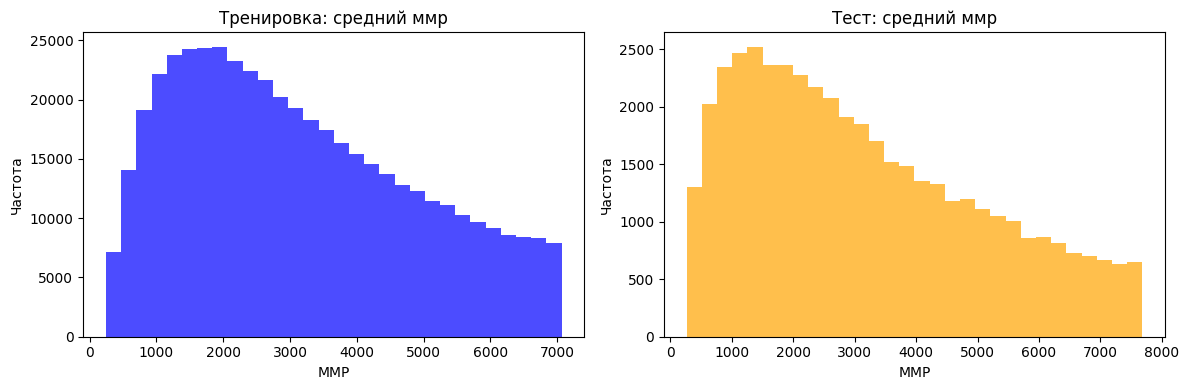

KS между train и test: nan, p-value: nan


In [49]:
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(matches_train['avg_mmr'], bins=30, alpha=0.7, color='blue')
axes[0].set_title('Тренировка: средний ммр')
axes[0].set_xlabel('ММР')
axes[0].set_ylabel('Частота')
axes[1].hist(matches_test['avg_mmr'], bins=30, alpha=0.7, color='orange')
axes[1].set_title('Тест: средний ммр')
axes[1].set_xlabel('ММР')
axes[1].set_ylabel('Частота')
plt.tight_layout()
plt.show()
ks_result = ks_2samp(matches_train['avg_mmr'], matches_test['avg_mmr'])
print(f"KS между train и test: {ks_result.statistic:.3f}, p-value: {ks_result.pvalue:.3f}")

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** Оно похоже на нормальное распределение или "колокол".

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

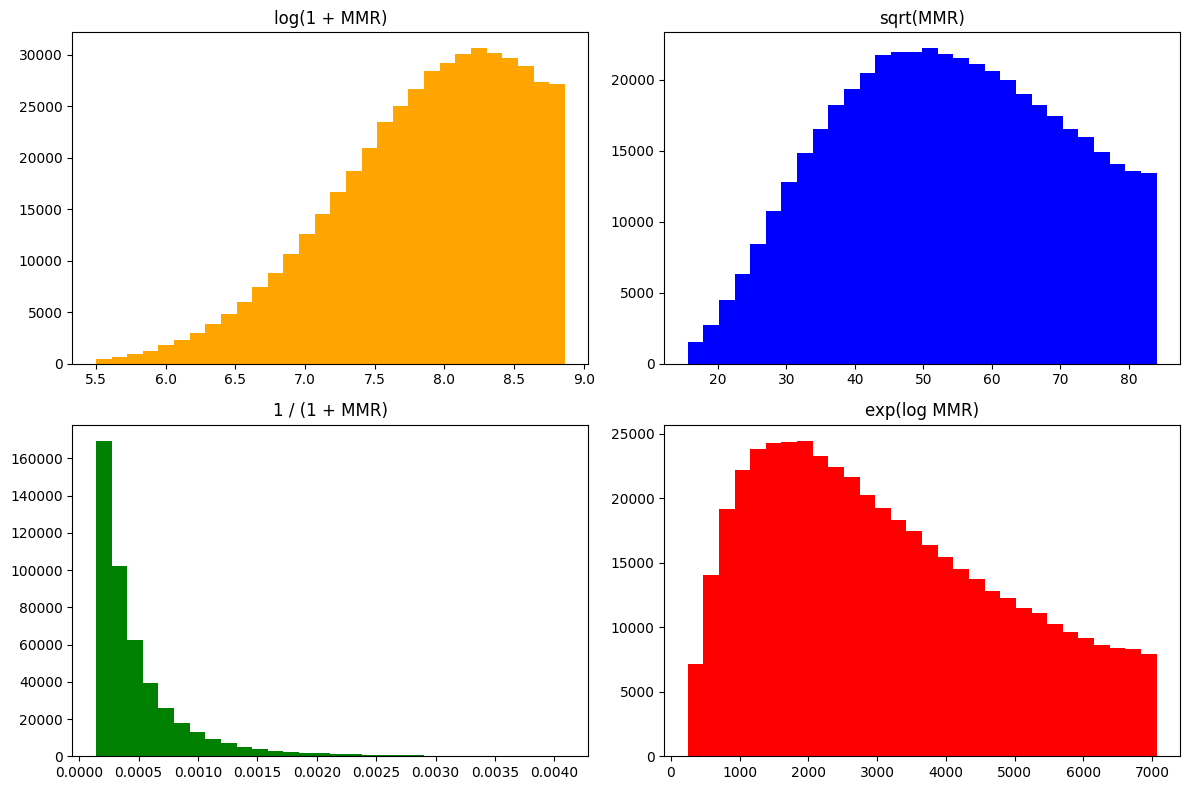

In [50]:
import numpy as np
import matplotlib.pyplot as plt

mmr_values = matches_train['avg_mmr']
log_transform = np.log1p(mmr_values)
sqrt_transform = np.sqrt(mmr_values)
inv_transform = 1 / (1 + mmr_values)
exp_transform = np.exp(np.log(mmr_values))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(log_transform, bins=30, color='orange')
axes[0, 0].set_title('log(1 + MMR)')
axes[0, 1].hist(sqrt_transform, bins=30, color='blue')
axes[0, 1].set_title('sqrt(MMR)')
axes[1, 0].hist(inv_transform, bins=30, color='green')
axes[1, 0].set_title('1 / (1 + MMR)')
axes[1, 1].hist(exp_transform, bins=30, color='red')
axes[1, 1].set_title('exp(log MMR)')
plt.tight_layout()
plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Мне каажется не надо заполнять пропуски нулём, лучше создать флаг mmr_missing и дополнительно заполнить пропуски более подходящим значением (например, медианой).

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [59]:
matches_train = pd.read_csv('matches_df_train.csv')
matches_test = pd.read_csv('matches_df_test.csv')
matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])
matches_train['day_of_week'] = matches_train['date'].dt.dayofweek
matches_train['day_of_month'] = matches_train['date'].dt.day
matches_test['day_of_week'] = matches_test['date'].dt.dayofweek
matches_test['day_of_month'] = matches_test['date'].dt.day
encoder_region = ce.TargetEncoder()
matches_train['region_encoded'] = encoder_region.fit_transform(matches_train['region'], matches_train['radiant_win'])
matches_test['region_encoded'] = encoder_region.transform(matches_test['region'])
encoder_game_mode = ce.TargetEncoder()
matches_train['game_mode_encoded'] = encoder_game_mode.fit_transform(matches_train['game_mode'], matches_train['radiant_win'])
matches_test['game_mode_encoded'] = encoder_game_mode.transform(matches_test['game_mode'])
matches_train['log_avg_mmr'] = np.log1p(matches_train['avg_mmr'])
matches_test['log_avg_mmr'] = np.log1p(matches_test['avg_mmr'])
features_both = ['region_encoded', 'day_of_week', 'day_of_month', 'avg_mmr']
features_log = features_both + ['log_avg_mmr']
X_train_base = matches_train[features_both]
X_train_log = matches_train[features_log]
X_test_base = matches_test[features_both]
X_test_log = matches_test[features_log]
y = matches_train['radiant_win'].astype(int)
def train_evaluate_model(X, y, description):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipeline.fit(X, y)
    y_pred_prob = pipeline.predict_proba(X)[:, 1]
    score = roc_auc_score(y, y_pred_prob)
    print(f"{description} — ROC AUC: {score:.4f}")
    return pipeline, score
print("Обучение модели без log_avg_mmr")
model_without_transform, score_without_transform = train_evaluate_model(X_train_base, y, "по датам + регионам + базовые признаки")
print("\nОбучение модели с log_avg_mmr")
model_with_transform, score_with_transform = train_evaluate_model(X_train_log, y, "по датам + регионам + базовые признаки + log_avg_mmr")
print("\nРезультаты:")
print(f"Без преобразования: ROC AUC = {score_without_transform:.4f}")
print(f"С log_avg_mmr: {score_with_transform:.4f}")

Обучение модели без log_avg_mmr
по датам + регионам + базовые признаки — ROC AUC: 0.5584

Обучение модели с log_avg_mmr
по датам + регионам + базовые признаки + log_avg_mmr — ROC AUC: 0.5561

Результаты:
Без преобразования: ROC AUC = 0.5584
С log_avg_mmr: 0.5561


### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [61]:
import pandas as pd

players_df = pd.read_csv('player_df.csv')
heroes_df = pd.read_csv('Constants.Heroes.csv')
print(players_df['account_id'].unique())
print(players_df['account_id'].value_counts())
anomalous_ids = players_df['account_id'][players_df['account_id'].isin([0, -1])]
print("Аномальные ID (обычно анонимные):", anomalous_ids.unique())
players_clean = players_df[~players_df['account_id'].isin([0, -1])]
print(heroes_df.head())
print(heroes_df.info())
heroes_clean = heroes_df[heroes_df['id'].between(1, 200)]


[ 10111871  43341844  72157343 ... 156405264 103714666 114328757]
account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 143460977           1
 183538415           1
 156099649           1
 122645735           1
 168542425           1
Name: count, Length: 974931, dtype: int64
Аномальные ID (обычно анонимные): [-1]
   Unnamed: 0  id                          name primary_attr attack_type  \
0           0   1        npc_dota_hero_antimage          agi       Melee   
1           1   2             npc_dota_hero_axe          str       Melee   
2           2   3            npc_dota_hero_bane          all      Ranged   
3           3   4     npc_dota_hero_bloodseeker          agi       Melee   
4           4   5  npc_dota_hero_crystal_maiden          int      Ranged   

                                           roles  \
0                   ['Carry', 'Escape', 'Nuker']   
1  ['Initiator', 'Durable', 

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** Да, можно, потому что такие аккаунты скорее всего не представляют реенных игроков и их удаление не повлияет на качество данных, а наоборот - избавит от шумов и ошибок.

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [66]:
matches_grouped = players_df.groupby('match_id')
matches_with_duplicates = []

for match_id, group in matches_grouped:
    total_heroes = len(group)
    unique_heroes = group['hero_id'].nunique()
    if unique_heroes < total_heroes:
        matches_with_duplicates.append(match_id)
print(f"Количество матчей с дублями: {len(matches_with_duplicates)}")
players_df_clean = players_df[~players_df['match_id'].isin(matches_with_duplicates)]

Количество матчей с дублями: 1053


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [70]:
matches_with_hero_zero=players_df[players_df['hero_id']==0]['match_id'].unique()
players_df=players_df[~players_df['match_id'].isin(matches_with_hero_zero)]
light_team_slots=[0,1,2,3,4]
dark_team_slots=[128,129,130,131,132]
grouped=players_df.groupby('match_id')
matches_with_both_teams=[]
for match_id,group in grouped:
    has_light=group['player_slot'].isin(light_team_slots).any()
    has_dark=group['player_slot'].isin(dark_team_slots).any()
    if has_light and has_dark:
        matches_with_both_teams.append(match_id)
players_df=players_df[~players_df['match_id'].isin(matches_with_both_teams)]
valid_matches=[]
for match_id,group in players_df.groupby('match_id'):
    counts=group['player_slot'].value_counts()
    num_light=counts.reindex(light_team_slots, fill_value=0).sum()
    num_dark=counts.reindex(dark_team_slots, fill_value=0).sum()
    if num_light==5 and num_dark==5:
        valid_matches.append(match_id)
players_df=players_df[players_df['match_id'].isin(valid_matches)]

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [72]:
from scipy.sparse import csr_matrix
import numpy as np

class HeroesEncoder:
    def __init__(self):
        self.hero_to_index = {}
        self.n_heroes = 0

    def fit(self, X, y=None):
        unique_heroes = X['hero_id'].unique()
        self.hero_to_index = {hero_id: idx for idx, hero_id in enumerate(unique_heroes)}
        self.n_heroes = len(unique_heroes)
        return self

    def transform(self, X, y=None):
        match_ids = X['match_id'].unique()
        rows = []
        cols = []
        data = []
        grouped = X.groupby('match_id')
        for match_id, group in grouped:
            for _, row in group.iterrows():
                hero_idx = self.hero_to_index[row['hero_id']]
                val = 1 if row['player_slot'] in [0,1,2,3,4] else -1 if row['player_slot'] in [128,129,130,131,132] else 0
                if val != 0:
                    rows.append(match_id)
                    cols.append(hero_idx)
                    data.append(val)
        match_id_to_idx = {mid: idx for idx, mid in enumerate(match_ids)}
        row_indices = [match_id_to_idx[mid] for mid in rows]
        shape = (len(match_ids), self.n_heroes)
        return csr_matrix((data, (row_indices, cols)), shape=shape)

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

train_path = 'matches_df_train.csv'
test_path  = 'matches_df_test.csv'
matches_train = pd.read_csv(train_path)
matches_test  = pd.read_csv(test_path)

def detect_target(df):
    for col in ['radiant_win','Radiant_win','winner','result','is_radiant_win']:
        if col in df.columns:
            return col
    raise ValueError('Целевой столбец не найден среди: radiant_win, Radiant_win, winner, result, is_radiant_win')
target_col = detect_target(matches_train)

matches_train = matches_train[~matches_train[target_col].isna()].copy()
y = matches_train[target_col].astype(int).values
if 'date' in matches_train.columns:
    matches_train['date'] = pd.to_datetime(matches_train['date'])
    matches_train['day_of_week'] = matches_train['date'].dt.dayofweek
    matches_train['day_of_month'] = matches_train['date'].dt.day
else:
    matches_train['day_of_week'] = 0
    matches_train['day_of_month'] = 0

if 'date' in matches_test.columns:
    matches_test['date'] = pd.to_datetime(matches_test['date'])
    matches_test['day_of_week'] = matches_test['date'].dt.dayofweek
    matches_test['day_of_month'] = matches_test['date'].dt.day
else:
    matches_test['day_of_week'] = 0
    matches_test['day_of_month'] = 0

def apply_target_encoder(train_df, test_df, target_col, colname, new_col):
    if colname in train_df.columns and colname in test_df.columns:
        enc = ce.TargetEncoder(cols=[colname])
        train_enc = enc.fit_transform(train_df[[colname]], train_df[target_col].astype(int))
        test_enc  = enc.transform(test_df[[colname]])
        train_df[new_col] = train_enc[colname]
        test_df[new_col]  = test_enc[colname]
    else:
        train_df[new_col] = 0
        test_df[new_col]  = 0
    return train_df, test_df

matches_train, matches_test = apply_target_encoder(matches_train, matches_test, target_col, 'region', 'region_encoded')
matches_train, matches_test  = apply_target_encoder(matches_train, matches_test, target_col, 'game_mode', 'game_mode_encoded')

default_base_features = ['duration','avg_mmr','day_of_week','day_of_month','region_encoded','game_mode_encoded']
available_features = [c for c in default_base_features if c in matches_train.columns]
print("Используемые базовые признаки:", available_features)

if len(available_features) == 0:
    numeric_cols = matches_train.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target_col]
    available_features = numeric_cols
    print("Fallback на числовые признаки:", available_features)

hero_df = None
for name in ['player_df','players_df']:
    if name in globals():
        hero_df = globals()[name].copy()
        break

hero_features_df = None
if hero_df is not None:
    if 'hero_id' in hero_df.columns:
        hero_df = hero_df[hero_df['hero_id'] != 0]

        light_team_slots = [0,1,2,3,4]
        dark_team_slots  = [128,129,130,131,132]
        grouped = hero_df.groupby('match_id')
        matches_with_both_teams = []
        for match_id, grp in grouped:
            has_light = grp['player_slot'].isin(light_team_slots).any()
            has_dark  = grp['player_slot'].isin(dark_team_slots).any()
            if has_light and has_dark:
                matches_with_both_teams.append(match_id)
        hero_df = hero_df[hero_df['match_id'].isin(matches_with_both_teams)]

        if not hero_df.empty:
            hero_counts = hero_df.groupby(['match_id','hero_id']).size().unstack(fill_value=0)
            if not hero_counts.empty:
                top_n = 20
                top_heroes = hero_counts.sum(axis=0).sort_values(ascending=False).head(top_n).index.tolist()
                hero_counts = hero_counts[top_heroes]
                hero_features_df = hero_counts.copy()
    else:
        print("В hero_df нет столбца 'hero_id'. Герои-фичи не будут использоваться.")

if hero_features_df is not None:
    print("Геро-фичи будут использоваться (кол-во матчей:", hero_features_df.shape[0], ", героев:", hero_features_df.shape[1], ")")
else:
    print("Геро-фичи не доступны (hero_df отсутствует или недостаточно данных).")

train_matches_df = matches_train.copy()
train_matches_df['match_id'] = train_matches_df['match_id'].astype(int)

X_base = train_matches_df[available_features].copy().reset_index(drop=True)

if hero_features_df is not None:
    hero_train = train_matches_df[['match_id']].merge(hero_features_df, left_on='match_id', right_index=True, how='left')
    hero_train = hero_train.drop(columns=['match_id']).fillna(0).reset_index(drop=True)
    X_train_final = pd.concat([X_base, hero_train], axis=1)
else:
    X_train_final = X_base.copy()

test_base = matches_test.copy()
missing_in_test = [c for c in available_features if c not in test_base.columns]
for c in missing_in_test:
    test_base[c] = 0
X_test_base = test_base[available_features].copy().reset_index(drop=True)

if hero_features_df is not None:
    hero_test = matches_test[['match_id']].merge(hero_features_df, left_on='match_id', right_index=True, how='left')
    hero_test = hero_test.drop(columns=['match_id']).fillna(0).reset_index(drop=True)
    X_test_final = pd.concat([X_test_base, hero_test], axis=1)
else:
    X_test_final = X_test_base.copy()

X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

if len(y) != len(X_train_final):
    min_len = min(len(y), len(X_train_final))
    y = y[:min_len]
    X_train_final = X_train_final.iloc[:min_len]

X_tr, X_val, y_tr, y_val = train_test_split(X_train_final, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y))>1 else None)

model_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_full.fit(X_tr, y_tr)

proba_val = model_full.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, proba_val)
acc = accuracy_score(y_val, model_full.predict(X_val))

print(f"Полные признаки + геро-фичи (если были): ROC-AUC={roc:.4f}, ACC={acc:.4f}")

if hero_features_df is not None:
    print("Геро-фичи присутствуют в модели (они добавлены в X_train_final).")
else:
    print("Геро-фичи не доступны или не применялись.")


Используемые базовые признаки: ['duration', 'avg_mmr', 'day_of_week', 'day_of_month', 'region_encoded', 'game_mode_encoded']
Геро-фичи не доступны (hero_df отсутствует или недостаточно данных).
Полные признаки + геро-фичи (если были): ROC-AUC=0.5408, ACC=0.5291
Геро-фичи не доступны или не применялись.


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [27]:
import optuna


def objective(trial):
    # model parameters
    params = {
        # смотрите доку
    }

    # fit
    # ...

    # predict
    gini_valid = gini(...)
    
    return gini_valid


study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=25)

ModuleNotFoundError: No module named 'optuna'

#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:**

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )